In [1]:
import pandas as pd
df = pd.read_csv("personagens_droides_star_wars.csv")
df

,Nome,Continuidade,Tipo,Espécie,Gênero,Planeta Natal,Altura,Massa,Nascimento,Morte,Famílias,Pais,Parceiros,Irmãos,Filhos,Mestres,Aprendizes,Afiliação
0,Brianna,Legends,Jedi,Human-Echani hybrid,Female,NaN,NaN,NaN,3976 BBY,NaN,NaN,Arren Kae; Yusanis,NaN,Handmaiden Sisters,NaN,Atris; Meetra Surik,NaN,Handmaiden Sisters; Lost Jedi
1,Atris,Legends,Jedi,Human,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jedi Order
2,Meetra Surik,Canon,Jedi,Human,Female,Dantooine,NaN,NaN,Roughly ten years before Bastila Shan,"3950 BBY, Dromund Kaas",NaN,NaN,NaN,NaN,NaN,Unidentified Jedi; Vima Sunrider; Kavar; Revan...,Atton Rand; Mical; Visas Marr,Jedi Order; Onderon Royalists
3,Ainlee Teem,Legends,Galactic Republic,Gran,NaN,Malastare,NaN,NaN,NaN,NaN,new,new,new,new,new,NaN,NaN,Galactic Republic; Galactic Senate
4,Palpatine,Legends,Sith,Human,Male,Naboo,1.73 / 1.78 meters,75 kilograms,82 BBY Naboo,"4 ABY , Death Star II (original body); 10 ABY ...",House Palpatine,Cosinga Palpatine,NaN,First brother; Second brother; First sister; S...,Triclops,Darth Plagueis,Darth Maul; Vergere; Darth Tyranus; Darth Vade...,Damask Holdings; Galactic Republic; Galactic E...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46739,Dona (Senator),Canon,Galactic Republic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Galactic Republic; Galactic Senate
46740,Apexx,Canon,NaN,NaN,NaN,NaN,NaN,NaN,Between 232 BBY and 230 BBY,NaN,NaN,Rek Minuu,NaN,NaN,NaN,NaN,NaN,Rek Minuu
46741,Kluurt,Canon,NaN,Gungan,NaN,Naboo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46742,Unidentified emotional-support droid,Canon,NaN,Emotional-support droid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Comparar diversidades de espécies entre o Legends e o Canon

In [2]:
Canon = df.loc[df['Continuidade'] == 'Canon']
Legends = df.loc[df['Continuidade'] == 'Legends']

In [3]:
print('Especies no Canon: ', Canon['Espécie'].nunique())
print('Especies no Legends: ', Legends['Espécie'].nunique())

Especies no Canon:  1084
Especies no Legends:  1460


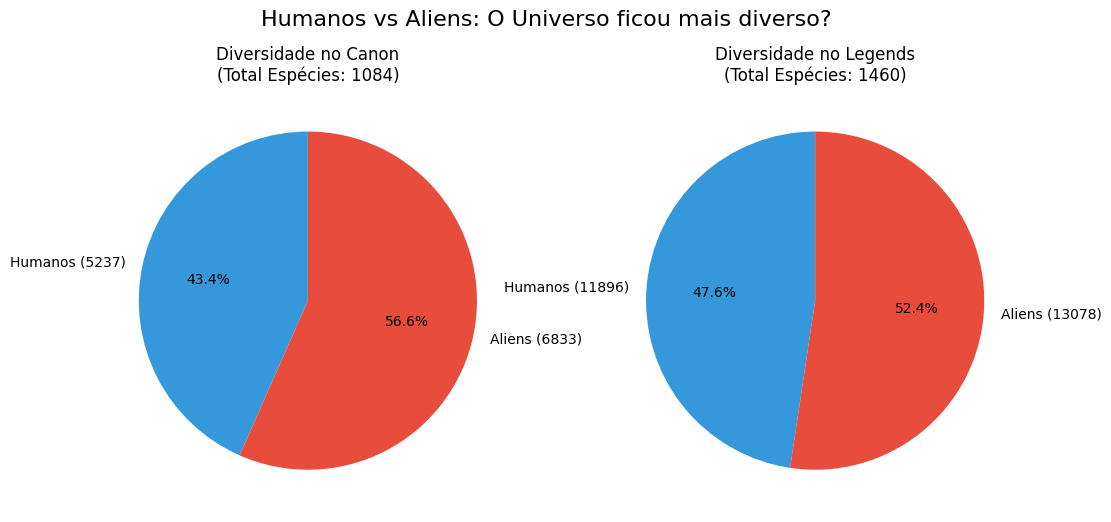

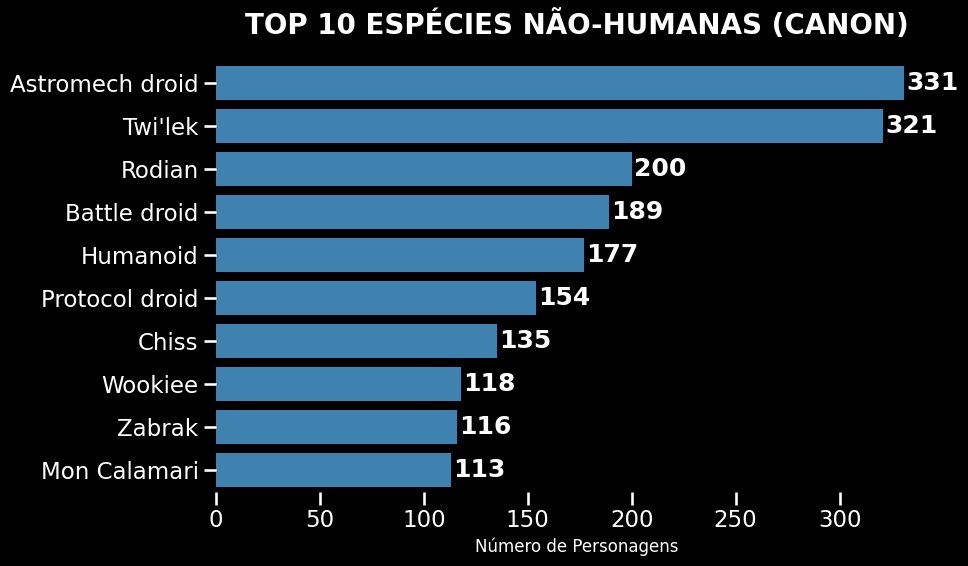

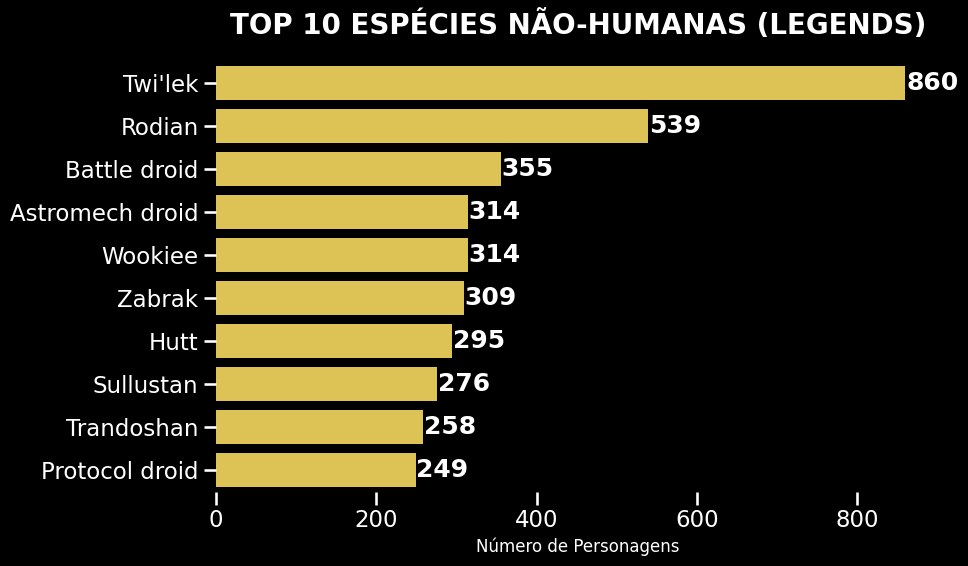

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Limpeza rápida: Padronizar 'Human' (as vezes aparece 'Human (Cyborg)', etc)
# Ajuste conforme o que aparecer no seu CSV
#df['Espécie'] = df['Espécie'].apply(lambda x: 'Human' if 'Human' in str(x) else x)

# --- GRÁFICO 1: A DOMINÂNCIA HUMANA ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

def plot_pizza(dataset, titulo, eixo):
    contagem = dataset['Espécie'].value_counts()
    humanos = contagem.get('Human', 0)
    outros = contagem.sum() - humanos
    
    dados = [humanos, outros]
    labels = [f'Humanos ({humanos})', f'Aliens ({outros})']
    colors = ['#3498db', '#e74c3c']
    
    eixo.pie(dados, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    eixo.set_title(titulo)

plot_pizza(Canon, f"Diversidade no Canon\n(Total Espécies: {Canon['Espécie'].nunique()})", ax[0])
plot_pizza(Legends, f"Diversidade no Legends\n(Total Espécies: {Legends['Espécie'].nunique()})", ax[1])

plt.suptitle("Humanos vs Aliens: O Universo ficou mais diverso?", fontsize=16)
plt.show()

# --- GRÁFICO 2: TOP 10 ESPÉCIES ALIENS (Sem Humanos e Sem 'N/A') ---
def get_top_aliens(dataset):
    # Filtra Humanos e N/A (Desconhecidos)
    filtro = (~dataset['Espécie'].isin(['Human', 'N/A', 'Unknown']))
    return dataset[filtro]['Espécie'].value_counts().head(10)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de Estilo "Sci-Fi"
plt.style.use('dark_background') # Fundo preto fica muito legal com Star Wars
sns.set_context("talk") # Aumenta o texto para ficar legível em slides/LinkedIn


# Filtra 'Human', 'N/A', 'Unknown' e variações vazias para focar nos Aliens/Droides
filtro_exclusao = ['Human', 'N/A', 'Unknown', 'nan']
df_limpo = df[~df['Espécie'].isin(filtro_exclusao)].copy()

# Remove também quem tem Espécie vazia (NaN)
df_limpo = df_limpo.dropna(subset=['Espécie'])

# Separa os universos
canon = df_limpo[df_limpo['Continuidade'] == 'Canon']
legends = df_limpo[df_limpo['Continuidade'] == 'Legends']

# --- FUNÇÃO DE PLOTAGEM ---
def plotar_top_species(dados, titulo, cor_barra):
    # Conta e pega o Top 10
    top_10 = dados['Espécie'].value_counts().head(10)
    
    # Cria a figura
    plt.figure(figsize=(10, 6))
    
    # Gráfico de Barras Horizontal
    ax = sns.barplot(x=top_10.values, y=top_10.index, color=cor_barra)
    
    # Perfumaria (Títulos e Labels)
    plt.title(titulo, fontsize=20, pad=20, fontweight='bold', color='white')
    plt.xlabel("Número de Personagens", fontsize=12)
    plt.ylabel("") # Remove o label "Espécie" que é óbvio
    
    # Adiciona o número na ponta da barra
    for i, v in enumerate(top_10.values):
        ax.text(v + 1, i, str(v), color='white', va='center', fontweight='bold')
        
    sns.despine(left=True, bottom=True) # Remove bordas feias
    plt.tight_layout()
    plt.show()

# --- GERAR OS GRÁFICOS ---

# 1. CANON (Vamos usar Azul Jedi)
plotar_top_species(canon, "TOP 10 ESPÉCIES NÃO-HUMANAS (CANON)", "#2E86C1")

# 2. LEGENDS (Vamos usar Vermelho Sith ou Amarelo Logo)
plotar_top_species(legends, "TOP 10 ESPÉCIES NÃO-HUMANAS (LEGENDS)", "#F4D03F")

In [5]:
Canon[Canon['Espécie'] == 'Hutt']

,Nome,Continuidade,Tipo,Espécie,Gênero,Planeta Natal,Altura,Massa,Nascimento,Morte,Famílias,Pais,Parceiros,Irmãos,Filhos,Mestres,Aprendizes,Afiliação
144,Zorba Desilijic Tiure,Canon,Hutt Cartel,Hutt,Male,Nal Hutta,NaN,NaN,c. 1000 BBY,After 10 ABY,Desilijic,Mama,NaN,Jiliac Desilijic Tiron; Ebor,Jabba Desilijic Tiure,NaN,NaN,Desilijic kajidic; Jabba Desilijic Tiure's cri...
688,Durga Besadii Tai,Canon,Hutt Cartel,Hutt,Male,Nal Hutta,3.7 meters (length),NaN,105 BBY,12 ABY aboard Darksaber,Besadii,Aruk Besadii Aora,NaN,NaN,NaN,NaN,NaN,Hutt Cartel; Black Sun
1477,Durga,Canon,NaN,Hutt,NaN,NaN,NaN,NaN,NaN,NaN,new,new,new,new,new,NaN,NaN,NaN
1603,Zorba,Canon,Hutt Cartel,Hutt,Male,NaN,NaN,NaN,NaN,NaN,new,new,new,new,new,NaN,NaN,NaN
2777,Nuubsal,Canon,Criminal,Hutt,Male,NaN,NaN,NaN,NaN,"Sometime during the Galactic Civil War, Tarnta...",new,new,new,new,new,NaN,NaN,Consolidations Unlimited
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44531,Neyfig,Canon,Hutt Cartel,Hutt,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44735,Unidentified Hutt (Lanupa),Canon,NaN,Hutt,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
44740,Churo and Dahara's mother,Canon,NaN,Hutt,Female,NaN,NaN,NaN,NaN,NaN,NaN,Churo and Dahara's father,NaN,NaN,Churo; Dahara Devirsivik Norri.,NaN,NaN,Devirsivik Clan
45067,Unidentified Hutt clan leader,Canon,NaN,Hutt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
Canon['Espécie'].value_counts().head(11)

Espécie
Human              5237
Astromech droid     331
Twi'lek             321
Rodian              200
Battle droid        189
Humanoid            177
Protocol droid      154
Chiss               135
Wookiee             118
Zabrak              116
Mon Calamari        113
Name: count, dtype: int64

## 2. Analisando Jedi e Sith 

Primeiro Canon, depois Legends

In [7]:
pd.set_option('display.max_rows', None)
#Canon
JediC = Canon[Canon['Tipo']== 'Jedi']
JediC = JediC[['Nome', 'Tipo', 'Espécie', 'Morte', 'Afiliação']]
print('Antes de tirar Nan', JediC.size)
JediC = JediC.dropna(subset=['Morte'])
print('Após tirar Nan', JediC.size)

Antes de tirar Nan 4605
Após tirar Nan 1335


In [8]:
#Canon
SithC = Canon[Canon['Tipo']== 'Sith']
SithC = SithC[['Nome', 'Tipo', 'Espécie', 'Morte', 'Afiliação']]
print('Antes de tirar Nan', SithC.size)
SithC = SithC.dropna(subset=['Morte'])
print('Após tirar Nan', SithC.size)

Antes de tirar Nan 690
Após tirar Nan 200


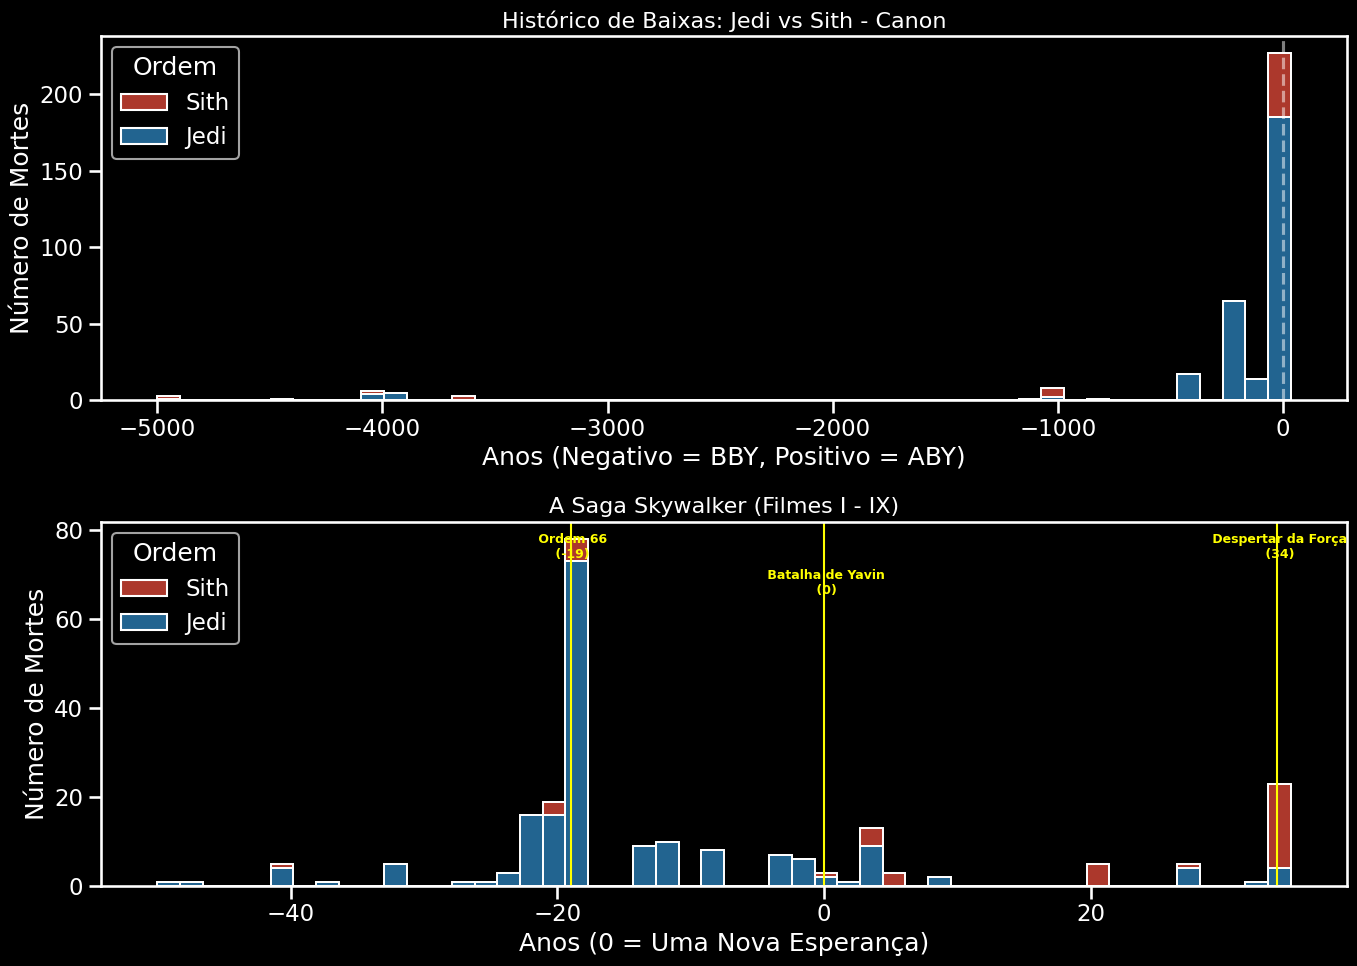

Total de mortes datadas processadas: 353

Top 5 Anos mais mortais para Jedi:
295
58


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Carrega seu CSV (Assumindo que você está com o arquivo v5)
df = Canon.copy()

# --- 1. FUNÇÃO DE LIMPEZA (A MÁGICA) ---
def extrair_ano_morte(texto):
    if not isinstance(texto, str):
        return None
    
    # Normaliza para maiúsculo para facilitar
    texto = texto.upper()
    
    # REGEX EXPLICADA:
    # (\d+(?:,\d+)?) -> Procura um número (ex: 19 ou 5,000)
    # \s* -> Pode ter espaço ou não
    # (BBY|ABY)      -> Tem que ser seguido de BBY ou ABY
    match = re.search(r'(\d+(?:,\d+)?)\s*(BBY|ABY)', texto)
    
    if match:
        numero_str = match.group(1).replace(',', '') # Remove vírgula de milhar (5,000 -> 5000)
        era = match.group(2)
        
        valor = float(numero_str)
        
        if era == 'BBY':
            return -valor  # Antes de Yavin é negativo
        else:
            return valor   # Depois de Yavin é positivo
            
    return None # Se não achou o padrão, retorna vazio

# --- 2. APLICAR A LIMPEZA ---
# Cria a coluna numérica
df['Ano_Morte_Float'] = df['Morte'].apply(extrair_ano_morte)

# Filtra apenas Jedi e Sith que tenham data de morte válida
# Usamos str.contains para pegar "Jedi", "Sith", "Dark Jedi", etc. na coluna Afiliação ou Tipo
filtro_force_users = df['Afiliação'].str.contains('Jedi|Sith', case=False, na=False) | \
                     df['Tipo'].str.contains('Jedi|Sith', case=False, na=False)

df_timeline = df[filtro_force_users & df['Ano_Morte_Float'].notna()].copy()

# Classifica quem é Jedi e quem é Sith para colorir o gráfico
def classificar_ordem(row):
    afiliacao = str(row['Afiliação']).lower() + str(row['Tipo']).lower()
    if 'sith' in afiliacao:
        return 'Sith'
    elif 'jedi' in afiliacao:
        return 'Jedi'
    return 'Outro'

df_timeline['Ordem'] = df_timeline.apply(classificar_ordem, axis=1)

# --- 3. VISUALIZAÇÃO (HISTOGRAMA HISTÓRICO) ---
plt.style.use('dark_background')
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

ordem_desejada = ['Sith', 'Jedi']
# GRÁFICO 1: VISÃO GERAL (Milhares de anos)
filtro_zoom = (df_timeline['Ano_Morte_Float'] >= -5500) & (df_timeline['Ano_Morte_Float'] <= 100)
df_zoom = df_timeline[filtro_zoom]
sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Ordem', 
             multiple='stack', bins=50, palette={'Jedi': '#2E86C1', 'Sith': '#E74C3C', 'Outro': 'gray'}, ax=ax[0], hue_order=ordem_desejada)
ax[0].set_title('Histórico de Baixas: Jedi vs Sith - Canon', fontsize=16)
ax[0].set_xlabel('Anos (Negativo = BBY, Positivo = ABY)')
ax[0].set_ylabel('Número de Mortes')
ax[0].axvline(0, color='white', linestyle='--', alpha=0.5) # Linha da Batalha de Yavin

# GRÁFICO 2: ZOOM NA ERA DOS FILMES (-50 a +50)
# É aqui que vamos ver a Ordem 66
filtro_zoom = (df_timeline['Ano_Morte_Float'] >= -50) & (df_timeline['Ano_Morte_Float'] <= 50)
df_zoom = df_timeline[filtro_zoom]

sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Ordem', 
             multiple='stack', bins=50, palette={'Jedi': '#2E86C1', 'Sith': '#E74C3C', 'Outro': 'gray'}, ax=ax[1], hue_order=ordem_desejada)
ax[1].set_title('A Saga Skywalker (Filmes I - IX)', fontsize=16)
ax[1].set_xlabel('Anos (0 = Uma Nova Esperança)')
ax[1].set_ylabel('Número de Mortes')

# 1. Ordem 66 (-19 BBY)
ax[1].axvline(-19, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(-19, ax[1].get_ylim()[1]*0.9, ' Ordem 66\n (-19)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 2. Uma Nova Esperança (0 BBY/ABY)
ax[1].axvline(0, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(0, ax[1].get_ylim()[1]*0.8, ' Batalha de Yavin\n (0)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 3. O Despertar da Força (34 ABY)
# O filme se passa 30 anos após o Episódio 6 (que foi em 4 ABY), logo: 34 ABY.
ax[1].axvline(34, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(34, ax[1].get_ylim()[1]*0.9, ' Despertar da Força\n (34)', color='yellow', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# --- EXIBIR OS DADOS CURIOSOS ---
print("Total de mortes datadas processadas:", len(df_timeline))
print("\nTop 5 Anos mais mortais para Jedi:")
print(df_timeline[df_timeline['Ordem']=='Jedi']['Ano_Morte_Float'].count())
print(df_timeline[df_timeline['Ordem']=='Sith']['Ano_Morte_Float'].count())

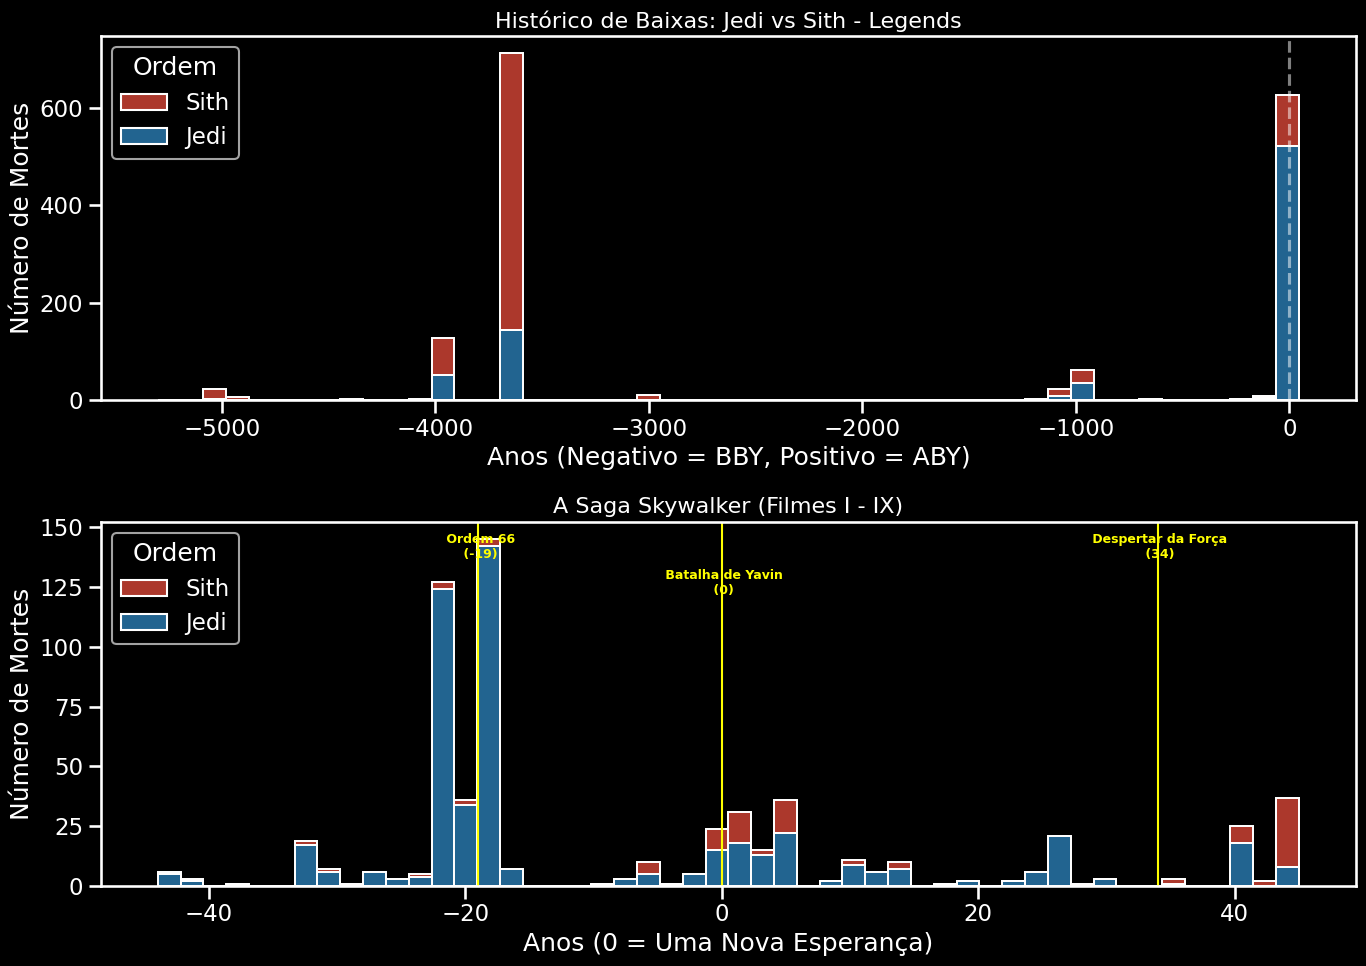

Total de mortes datadas processadas: 1712

Top 5 Anos mais mortais para Jedi:
805
907


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Carrega seu CSV (Assumindo que você está com o arquivo v5)
df = Legends.copy()

# --- 1. FUNÇÃO DE LIMPEZA (A MÁGICA) ---
def extrair_ano_morte(texto):
    if not isinstance(texto, str):
        return None
    
    # Normaliza para maiúsculo para facilitar
    texto = texto.upper()
    
    # REGEX EXPLICADA:
    # (\d+(?:,\d+)?) -> Procura um número (ex: 19 ou 5,000)
    # \s* -> Pode ter espaço ou não
    # (BBY|ABY)      -> Tem que ser seguido de BBY ou ABY
    match = re.search(r'(\d+(?:,\d+)?)\s*(BBY|ABY)', texto)
    
    if match:
        numero_str = match.group(1).replace(',', '') # Remove vírgula de milhar (5,000 -> 5000)
        era = match.group(2)
        
        valor = float(numero_str)
        
        if era == 'BBY':
            return -valor  # Antes de Yavin é negativo
        else:
            return valor   # Depois de Yavin é positivo
            
    return None # Se não achou o padrão, retorna vazio

# --- 2. APLICAR A LIMPEZA ---
# Cria a coluna numérica
df['Ano_Morte_Float'] = df['Morte'].apply(extrair_ano_morte)

# Filtra apenas Jedi e Sith que tenham data de morte válida
# Usamos str.contains para pegar "Jedi", "Sith", "Dark Jedi", etc. na coluna Afiliação ou Tipo
filtro_force_users = df['Afiliação'].str.contains('Jedi|Sith', case=False, na=False) | \
                     df['Tipo'].str.contains('Jedi|Sith', case=False, na=False)

df_timeline = df[filtro_force_users & df['Ano_Morte_Float'].notna()].copy()

# Classifica quem é Jedi e quem é Sith para colorir o gráfico
def classificar_ordem(row):
    afiliacao = str(row['Afiliação']).lower() + str(row['Tipo']).lower()
    if 'sith' in afiliacao:
        return 'Sith'
    elif 'jedi' in afiliacao:
        return 'Jedi'
    return 'Outro'

df_timeline['Ordem'] = df_timeline.apply(classificar_ordem, axis=1)

# --- 3. VISUALIZAÇÃO (HISTOGRAMA HISTÓRICO) ---
plt.style.use('dark_background')
fig, ax = plt.subplots(2, 1, figsize=(14, 10))

ordem_desejada = ['Sith', 'Jedi']
# GRÁFICO 1: VISÃO GERAL (Milhares de anos)
filtro_zoom = (df_timeline['Ano_Morte_Float'] >= -5500) & (df_timeline['Ano_Morte_Float'] <= 100)
df_zoom = df_timeline[filtro_zoom]
sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Ordem', 
             multiple='stack', bins=50, palette={'Jedi': '#2E86C1', 'Sith': '#E74C3C', 'Outro': 'gray'}, ax=ax[0], hue_order=ordem_desejada)
ax[0].set_title('Histórico de Baixas: Jedi vs Sith - Legends', fontsize=16)
ax[0].set_xlabel('Anos (Negativo = BBY, Positivo = ABY)')
ax[0].set_ylabel('Número de Mortes')
ax[0].axvline(0, color='white', linestyle='--', alpha=0.5) # Linha da Batalha de Yavin

# GRÁFICO 2: ZOOM NA ERA DOS FILMES (-50 a +50)
# É aqui que vamos ver a Ordem 66
filtro_zoom = (df_timeline['Ano_Morte_Float'] >= -50) & (df_timeline['Ano_Morte_Float'] <= 50)
df_zoom = df_timeline[filtro_zoom]

sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Ordem', 
             multiple='stack', bins=50, palette={'Jedi': '#2E86C1', 'Sith': '#E74C3C', 'Outro': 'gray'}, ax=ax[1], hue_order=ordem_desejada)
ax[1].set_title('A Saga Skywalker (Filmes I - IX)', fontsize=16)
ax[1].set_xlabel('Anos (0 = Uma Nova Esperança)')
ax[1].set_ylabel('Número de Mortes')

# 1. Ordem 66 (-19 BBY)
ax[1].axvline(-19, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(-19, ax[1].get_ylim()[1]*0.9, ' Ordem 66\n (-19)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 2. Uma Nova Esperança (0 BBY/ABY)
ax[1].axvline(0, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(0, ax[1].get_ylim()[1]*0.8, ' Batalha de Yavin\n (0)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 3. O Despertar da Força (34 ABY)
# O filme se passa 30 anos após o Episódio 6 (que foi em 4 ABY), logo: 34 ABY.
ax[1].axvline(34, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(34, ax[1].get_ylim()[1]*0.9, ' Despertar da Força\n (34)', color='yellow', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# --- EXIBIR OS DADOS CURIOSOS ---
print("Total de mortes datadas processadas:", len(df_timeline))
print("\nTop 5 Anos mais mortais para Jedi:")
print(df_timeline[df_timeline['Ordem']=='Jedi']['Ano_Morte_Float'].count())
print(df_timeline[df_timeline['Ordem']=='Sith']['Ano_Morte_Float'].count())

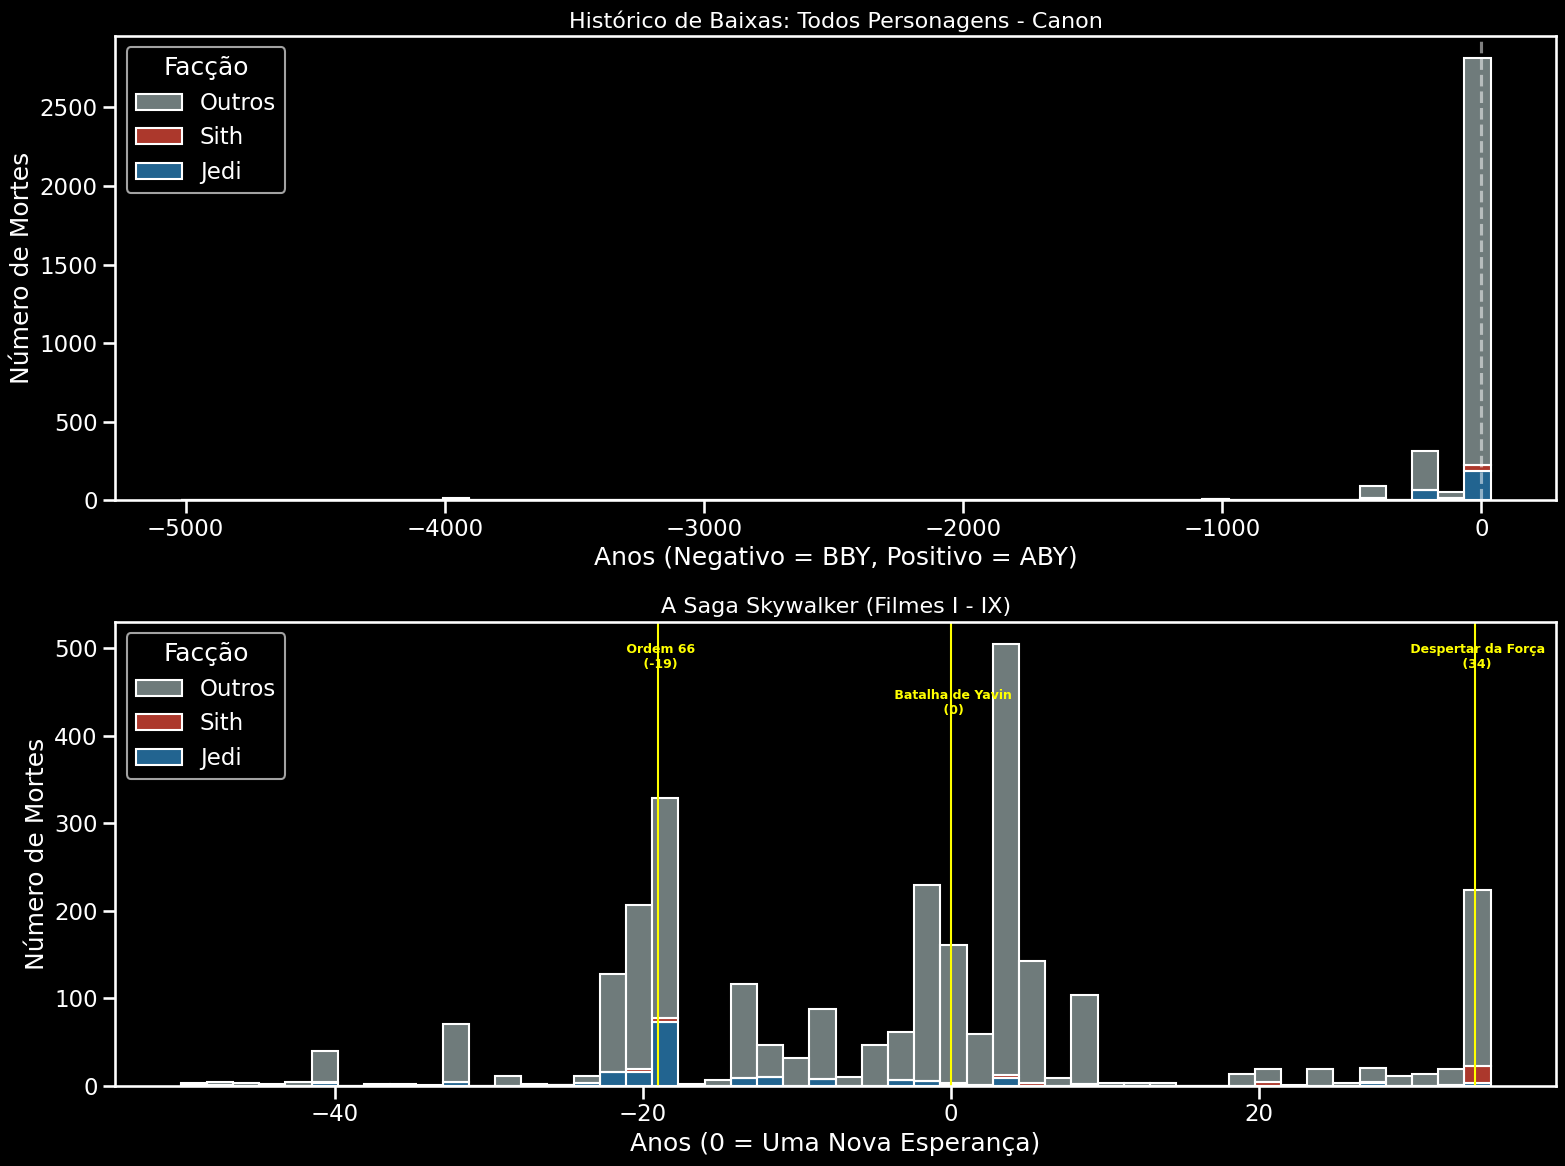

Total de mortes datadas analisadas: 3315

Contagem por Facção:
Facção
Outros    2962
Jedi       295
Sith        58
Name: count, dtype: int64

O ano mais mortal da história (segundo os dados):
Ano: 3.0 (Total: 272 mortes registradas)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re




df = Canon.copy()


# --- 2. TRATAMENTO DE DATAS (REGEX) ---
def limpar_ano_morte(texto):
    """Converte strings como '19 BBY', 'c. 4 ABY' em números float."""
    if not isinstance(texto, str):
        return None
    
    # Padroniza para maiúsculo
    texto = texto.upper()
    
    # Regex: Procura número (com ponto ou vírgula) seguido de BBY ou ABY
    # Ex: Pega '19' de 'c. 19 BBY'
    match = re.search(r'(\d+(?:[.,]\d+)?)\s*(BBY|ABY)', texto)
    
    if match:
        numero_str = match.group(1).replace(',', '') # Remove vírgula de milhar se houver
        era = match.group(2)
        
        try:
            valor = float(numero_str)
        except ValueError:
            return None
            
        if era == 'BBY':
            return -valor  # BBY é negativo
        else:
            return valor   # ABY é positivo
            
    return None

# Aplica a limpeza
df['Ano_Morte_Float'] = df['Morte'].apply(limpar_ano_morte)

# Remove quem não tem data de morte identificável
df_mortes = df.dropna(subset=['Ano_Morte_Float']).copy()

# --- 3. CLASSIFICAÇÃO (JEDI / SITH / OUTROS) ---
def classificar_faccao(row):
    # Junta as colunas de texto relevantes para buscar palavras-chave
    # Convertemos para string e minúsculo para garantir
    texto_busca = str(row['Afiliação']) + " " + str(row['Tipo']) + " " + str(row['Espécie'])
    texto_busca = texto_busca.lower()
    
    if 'sith' in texto_busca:
        return 'Sith'
    elif 'jedi' in texto_busca:
        return 'Jedi'
    else:
        return 'Outros'

df_mortes['Facção'] = df_mortes.apply(classificar_faccao, axis=1)

# --- 4. VISUALIZAÇÃO ---
plt.style.use('dark_background') # Tema Dark

# Criamos uma figura com 2 subplots (Visão Geral e Zoom)
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# Cores personalizadas
cores = {
    'Jedi': '#2E86C1',   # Azul
    'Sith': '#E74C3C',   # Vermelho
    'Outros': '#95A5A6'  # Cinza
}


ordem_desejada = ['Outros','Sith', 'Jedi']
# GRÁFICO 1: VISÃO GERAL (Milhares de anos)
filtro_zoom = (df_mortes['Ano_Morte_Float'] >= -5500) & (df_mortes['Ano_Morte_Float'] <= 100)
df_zoom = df_mortes[filtro_zoom]
sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Facção', 
             multiple='stack', bins=50, palette=cores, ax=ax[0], hue_order=ordem_desejada)
ax[0].set_title('Histórico de Baixas: Todos Personagens - Canon', fontsize=16)
ax[0].set_xlabel('Anos (Negativo = BBY, Positivo = ABY)')
ax[0].set_ylabel('Número de Mortes')
ax[0].axvline(0, color='white', linestyle='--', alpha=0.5) # Linha da Batalha de Yavin

# GRÁFICO 2: ZOOM NA ERA DOS FILMES (-50 a +50)
# É aqui que vamos ver a Ordem 66
filtro_zoom = (df_mortes['Ano_Morte_Float'] >= -50) & (df_mortes['Ano_Morte_Float'] <= 50)
df_zoom = df_mortes[filtro_zoom]

sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Facção', 
             multiple='stack', bins=50, palette=cores, ax=ax[1], hue_order=ordem_desejada)
ax[1].set_title('A Saga Skywalker (Filmes I - IX)', fontsize=16)
ax[1].set_xlabel('Anos (0 = Uma Nova Esperança)')
ax[1].set_ylabel('Número de Mortes')

# 1. Ordem 66 (-19 BBY)
ax[1].axvline(-19, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(-19, ax[1].get_ylim()[1]*0.9, ' Ordem 66\n (-19)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 2. Uma Nova Esperança (0 BBY/ABY)
ax[1].axvline(0, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(0, ax[1].get_ylim()[1]*0.8, ' Batalha de Yavin\n (0)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 3. O Despertar da Força (34 ABY)
# O filme se passa 30 anos após o Episódio 6 (que foi em 4 ABY), logo: 34 ABY.
ax[1].axvline(34, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(34, ax[1].get_ylim()[1]*0.9, ' Despertar da Força\n (34)', color='yellow', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
# --- ESTATÍSTICAS ---
print(f"Total de mortes datadas analisadas: {len(df_mortes)}")
print("\nContagem por Facção:")
print(df_mortes['Facção'].value_counts())

print("\nO ano mais mortal da história (segundo os dados):")
ano_max = df_mortes['Ano_Morte_Float'].mode()[0]
qtd_max = len(df_mortes[df_mortes['Ano_Morte_Float'] == ano_max])
print(f"Ano: {ano_max} (Total: {qtd_max} mortes registradas)")

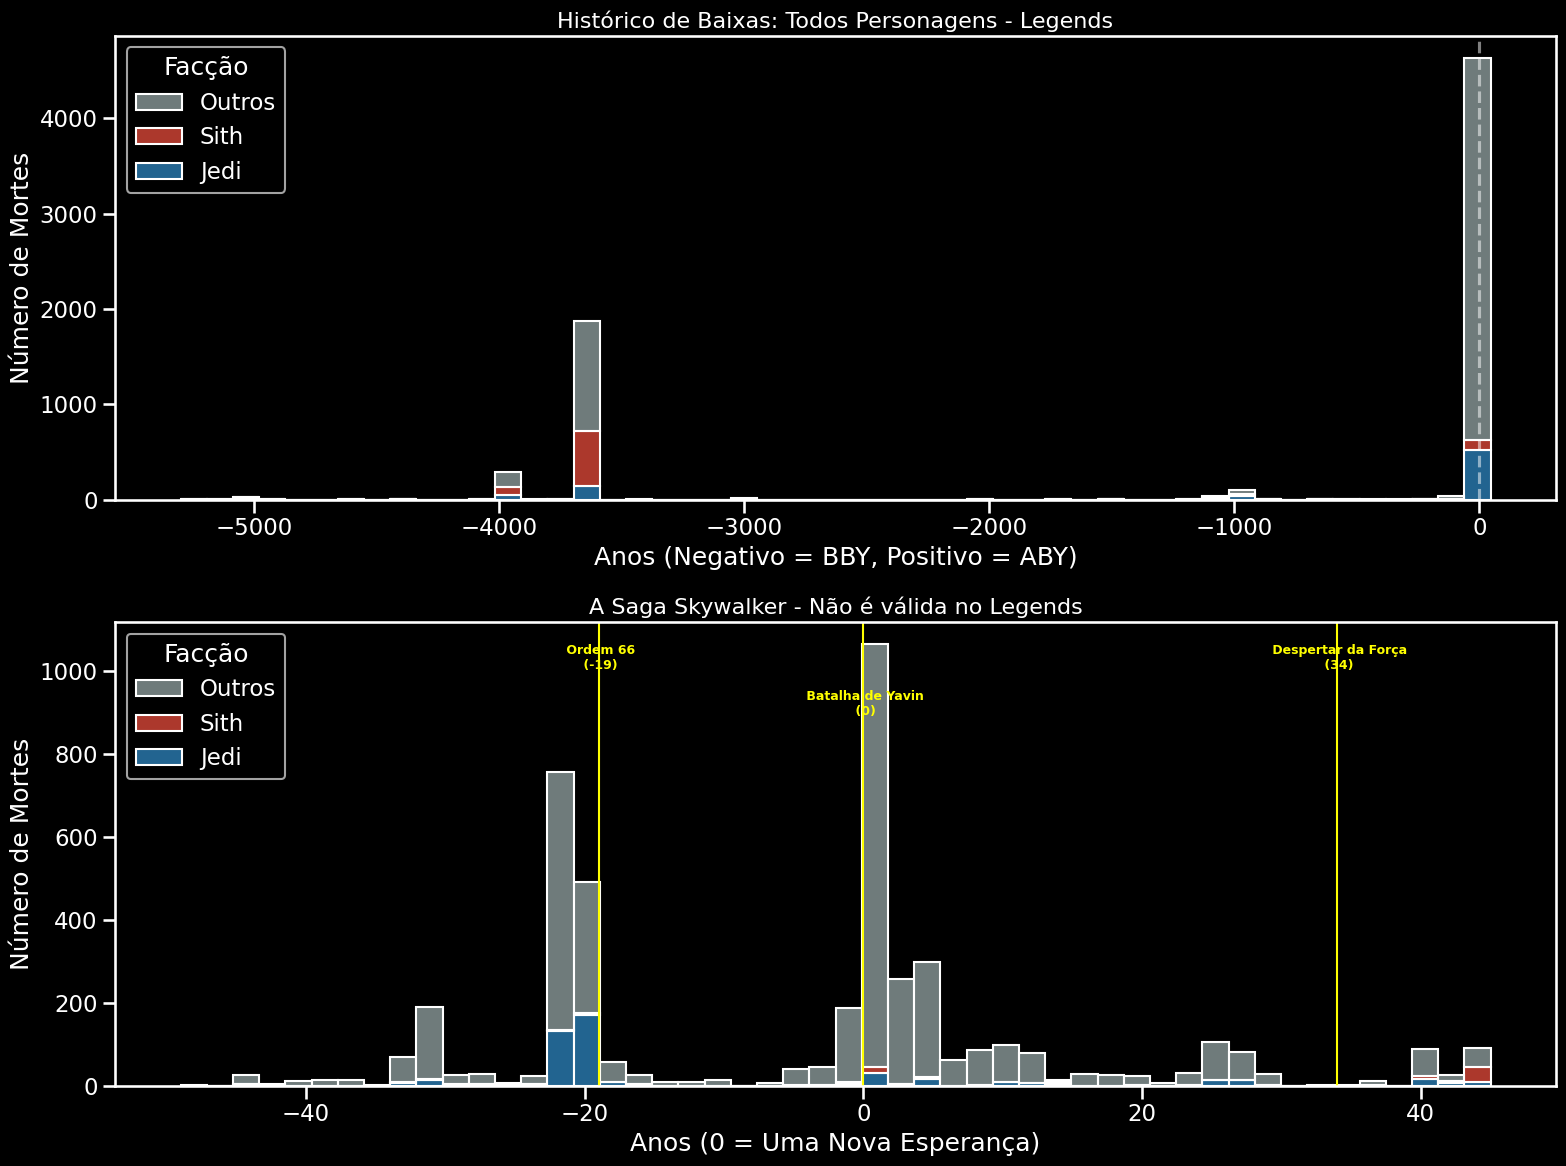

Total de mortes datadas analisadas: 7246

Contagem por Facção:
Facção
Outros    5529
Sith       912
Jedi       805
Name: count, dtype: int64

O ano mais mortal da história (segundo os dados):
Ano: -0.0 (Total: 601 mortes registradas)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re




df = Legends.copy()


# --- 2. TRATAMENTO DE DATAS (REGEX) ---
def limpar_ano_morte(texto):
    """Converte strings como '19 BBY', 'c. 4 ABY' em números float."""
    if not isinstance(texto, str):
        return None
    
    # Padroniza para maiúsculo
    texto = texto.upper()
    
    # Regex: Procura número (com ponto ou vírgula) seguido de BBY ou ABY
    # Ex: Pega '19' de 'c. 19 BBY'
    match = re.search(r'(\d+(?:[.,]\d+)?)\s*(BBY|ABY)', texto)
    
    if match:
        numero_str = match.group(1).replace(',', '') # Remove vírgula de milhar se houver
        era = match.group(2)
        
        try:
            valor = float(numero_str)
        except ValueError:
            return None
            
        if era == 'BBY':
            return -valor  # BBY é negativo
        else:
            return valor   # ABY é positivo
            
    return None

# Aplica a limpeza
df['Ano_Morte_Float'] = df['Morte'].apply(limpar_ano_morte)

# Remove quem não tem data de morte identificável
df_mortes = df.dropna(subset=['Ano_Morte_Float']).copy()

# --- 3. CLASSIFICAÇÃO (JEDI / SITH / OUTROS) ---
def classificar_faccao(row):
    # Junta as colunas de texto relevantes para buscar palavras-chave
    # Convertemos para string e minúsculo para garantir
    texto_busca = str(row['Afiliação']) + " " + str(row['Tipo']) + " " + str(row['Espécie'])
    texto_busca = texto_busca.lower()
    
    if 'sith' in texto_busca:
        return 'Sith'
    elif 'jedi' in texto_busca:
        return 'Jedi'
    else:
        return 'Outros'

df_mortes['Facção'] = df_mortes.apply(classificar_faccao, axis=1)

# --- 4. VISUALIZAÇÃO ---
plt.style.use('dark_background') # Tema Dark

# Criamos uma figura com 2 subplots (Visão Geral e Zoom)
fig, ax = plt.subplots(2, 1, figsize=(16, 12))

# Cores personalizadas
cores = {
    'Jedi': '#2E86C1',   # Azul
    'Sith': '#E74C3C',   # Vermelho
    'Outros': '#95A5A6'  # Cinza
}


ordem_desejada = ['Outros','Sith', 'Jedi']
# GRÁFICO 1: VISÃO GERAL (Milhares de anos)
filtro_zoom = (df_mortes['Ano_Morte_Float'] >= -5500) & (df_mortes['Ano_Morte_Float'] <= 100)
df_zoom = df_mortes[filtro_zoom]
sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Facção', 
             multiple='stack', bins=50, palette=cores, ax=ax[0], hue_order=ordem_desejada)
ax[0].set_title('Histórico de Baixas: Todos Personagens - Legends', fontsize=16)
ax[0].set_xlabel('Anos (Negativo = BBY, Positivo = ABY)')
ax[0].set_ylabel('Número de Mortes')
ax[0].axvline(0, color='white', linestyle='--', alpha=0.5) # Linha da Batalha de Yavin

# GRÁFICO 2: ZOOM NA ERA DOS FILMES (-50 a +50)
# É aqui que vamos ver a Ordem 66
filtro_zoom = (df_mortes['Ano_Morte_Float'] >= -50) & (df_mortes['Ano_Morte_Float'] <= 50)
df_zoom = df_mortes[filtro_zoom]

sns.histplot(data=df_zoom, x='Ano_Morte_Float', hue='Facção', 
             multiple='stack', bins=50, palette=cores, ax=ax[1], hue_order=ordem_desejada)
ax[1].set_title('A Saga Skywalker - Não é válida no Legends', fontsize=16)
ax[1].set_xlabel('Anos (0 = Uma Nova Esperança)')
ax[1].set_ylabel('Número de Mortes')

# 1. Ordem 66 (-19 BBY)
ax[1].axvline(-19, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(-19, ax[1].get_ylim()[1]*0.9, ' Ordem 66\n (-19)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 2. Uma Nova Esperança (0 BBY/ABY)
ax[1].axvline(0, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(0, ax[1].get_ylim()[1]*0.8, ' Batalha de Yavin\n (0)', color='yellow', ha='center', fontweight='bold', fontsize=9)

# 3. O Despertar da Força (34 ABY)
# O filme se passa 30 anos após o Episódio 6 (que foi em 4 ABY), logo: 34 ABY.
ax[1].axvline(34, color='yellow', linestyle='-', linewidth=1.5)
ax[1].text(34, ax[1].get_ylim()[1]*0.9, ' Despertar da Força\n (34)', color='yellow', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
# --- ESTATÍSTICAS ---
print(f"Total de mortes datadas analisadas: {len(df_mortes)}")
print("\nContagem por Facção:")
print(df_mortes['Facção'].value_counts())

print("\nO ano mais mortal da história (segundo os dados):")
ano_max = df_mortes['Ano_Morte_Float'].mode()[0]
qtd_max = len(df_mortes[df_mortes['Ano_Morte_Float'] == ano_max])
print(f"Ano: {ano_max} (Total: {qtd_max} mortes registradas)")